# Pythonizing Vincent!

In [1]:
import numpy as np
from typing import Union, Optional


# ------------------------------------------------------------
# 1) Ppi: build the orthogonal matrix V from first-order Pis
# ------------------------------------------------------------

def Ppi(Pi: Union[np.ndarray, list]) -> np.ndarray:
    """
    Python/Numpy port of the R function Ppi(Pi).

    Parameters
    ----------
    Pi : array-like of shape (N,)
        First-order inclusion probabilities, 0 < Pi_i < 1,
        sum(Pi) must be (approximately) an integer.

    Returns
    -------
    V : ndarray of shape (N, n)
        Orthogonal matrix associated to the DSD construction.
    """
    Pi = np.asarray(Pi, dtype=float).ravel()
    N = Pi.size

    # --- Error checks ---
    if N < 2:
        raise ValueError(
            "The sampling designs should be defined on a set of more than "
            "one element. (length(Pi) > 1)"
        )

    if np.any(Pi <= 0) or np.any(Pi >= 1):
        raise ValueError("Pi is not a vector of probabilities (0 < p < 1).")

    sum_pi_rounded = round(Pi.sum(), 9)
    n_int = int(sum_pi_rounded)
    if int(round(sum_pi_rounded, 9)) - sum_pi_rounded != 0:
        raise ValueError(
            "The sum of the first order inclusion probabilities "
            "should be an integer (up to rounding)."
        )

    # --- Main algorithm ---
    s_vals = np.zeros(N, dtype=float)
    c_vals = np.zeros(N, dtype=float)
    alpha = np.zeros(N, dtype=float)

    # kr will store the indices (0-based) where cumulative sum crosses integers
    if n_int <= 0:
        raise ValueError("Sum of Pi must be at least 1.")
    kr = [None] * n_int

    cum_sum = 0.0
    r = 1          # current integer threshold
    r_prev = 0     # last integer that was crossed

    for k in range(N):
        prev_sum = cum_sum
        cum_sum += Pi[k]

        if cum_sum >= r:  # crossed integer r
            if r <= n_int:
                alpha[k] = r - prev_sum
                kr[r - 1] = k   # store 0-based index
                val = np.sqrt((1.0 - Pi[k]) / (1.0 - alpha[k]))
                s_vals[k] = np.round(val, 8)
                r_prev = r
                r += 1
        else:
            denom = (r_prev + 1 - prev_sum)
            val = np.sqrt(Pi[k] / denom)
            s_vals[k] = np.round(val, 15)

        c_vals[k] = np.sqrt(1.0 - s_vals[k] ** 2)

    # Patch: ensure last crossing index corresponds to last unit (like R hack)
    # If some entries of kr are still None, set the last one to N-1.
    if any(x is None for x in kr):
        kr[-1] = N - 1
    # For safety, also replace any remaining None by the last index
    last_index = kr[-1]
    kr = [last_index if x is None else x for x in kr]

    # Use sample size n_int as number of columns (simplified vs. R hack)
    r_prev = n_int

    # --- Build V ---
    V = np.zeros((N, r_prev), dtype=float)
    V[0, 0] = 1.0

    # In R: V[kr[r] + 1, r + 1] = 1 for r in 1:(r_prev-1)
    # Here r_idx corresponds to r-1 in R, and we use 0-based indices.
    if r_prev - 1 != 0:
        for r_idx in range(1, r_prev):
            kpos = kr[r_idx - 1]  # 0-based index for row
            V[kpos + 1, r_idx] = 1.0

    # Apply Givens-like rotations
    for k in range(N - 1):
        L = V[k, :].copy()
        M = V[k + 1, :].copy()
        V[k, :] = s_vals[k] * L - c_vals[k] * M
        V[k + 1, :] = c_vals[k] * L + s_vals[k] * M

    return V


# ------------------------------------------------------------
# 2) DSD sampling (real and complex versions)
# ------------------------------------------------------------

def Drawing_Dsd(
    v: Union[np.ndarray, list],
    s: int = 1,
    B: bool = False,
    seed: Optional[int] = None,
):
    """
    Python/Numpy port of the R function Drawing_Dsd(v, s=1, B=FALSE, seed=NULL).

    Parameters
    ----------
    v : array-like, shape (N, n)
        Matrix of (real or complex) vectors used in DSD.
    s : int, default 1
        Number of samples (replicates).
    B : bool, default False
        If True: return 0/1 indicator vector(s).
        If False: return indices of selected units (1-based, to match R).
    seed : int or None
        Seed for reproducibility.

    Returns
    -------
    If s == 1:
        1D array of length N (if B=True) or selected indices (if B=False).
    If s > 1:
        2D array of shape (N, s) (if B=True) or (n, s) with indices per sample.
    """
    v = np.asarray(v)
    rng = np.random.default_rng(seed)

    if np.iscomplexobj(v):
        return _dsd_sampling_mult_complex(v, s, B, rng)
    else:
        return _dsd_sampling_mult(v, s, B, rng)


# ---------------------- helpers: real case ---------------------- #

def _dsd_sampling_mult(
    v: np.ndarray,
    s: int,
    B: bool,
    rng: np.random.Generator,
):
    v = np.asarray(v, dtype=float)
    if v.ndim == 1:
        v = v[:, None]  # treat as (N,1)

    if s == 1:
        return _dsd_sampling_01_B_C(v, B, rng)
    else:
        samples = [_dsd_sampling_01_B_C(v, B, rng) for _ in range(s)]
        # stack as columns like R's replicate (N x s)
        return np.column_stack(samples)


def _dsd_sampling_01_B_C(
    v: np.ndarray,
    B: bool = True,
    rng: Optional[np.random.Generator] = None,
):
    """
    Real-valued version of .dsd_sampling_01_B_C in R.
    """
    v = np.asarray(v, dtype=float)
    if v.ndim == 1:
        v = v[:, None]

    N, n = v.shape
    echant = np.zeros(N, dtype=int)

    if rng is None:
        rng = np.random.default_rng()
    ref = rng.random(n)

    # Step 1: first element
    w = v.copy()

    pi1 = np.einsum("ij,ij->i", v, v)  # diag(v %*% t(v))
    total = 0.0
    i = -1

    while total < ref[0]:
        i += 1
        if i >= N:
            raise RuntimeError("Sampling failed in first step (real case).")
        total += pi1[i] / n
    echant[i] = 1

    l = v[i, :]
    norm_l = np.sqrt(np.dot(l, l))
    if norm_l == 0:
        raise ValueError("Encountered zero-norm vector in real DSD.")
    e1 = l / norm_l

    # Step 2: remaining n-1 elements
    for j in range(n - 1):
        r = n - (j + 1)
        inter = v @ e1  # (N,)
        pi1 = pi1 - inter * inter
        pi2 = pi1 / r

        total = 0.0
        i = -1
        while total < ref[j + 1]:
            i += 1
            if i >= N:
                raise RuntimeError("Sampling failed in step 2 (real case).")
            total += pi2[i]
        echant[i] = 1

        # Update w and e1 (Gram-Schmidt-like update)
        proj = w @ e1                      # shape (N,)
        w = w - np.outer(proj, e1)         # (N,n)
        L = w[i, :]
        norm_L = np.sqrt(np.dot(L, L))
        if norm_L == 0:
            raise ValueError("Encountered zero-norm vector in real DSD.")
        e1 = L / norm_L

    if B:
        # 0/1 vector -> same as R "echant"
        return echant
    else:
        # indices (1-based, like in R: (1:N)[echant==1])
        return np.nonzero(echant == 1)[0] + 1


# -------------------- helpers: complex case --------------------- #

def _dsd_sampling_mult_complex(
    v: np.ndarray,
    s: int,
    B: bool,
    rng: np.random.Generator,
):
    v = np.asarray(v, dtype=np.complex128)
    if v.ndim == 1:
        v = v[:, None]

    if s == 1:
        return _dsd_sampling_01_B_C_complex(v, B, rng)
    else:
        samples = [_dsd_sampling_01_B_C_complex(v, B, rng) for _ in range(s)]
        return np.column_stack(samples)


def _dsd_sampling_01_B_C_complex(
    v: np.ndarray,
    B: bool = True,
    rng: Optional[np.random.Generator] = None,
):
    """
    Complex-valued version of .dsd_sampling_01_B_C_complex in R.
    """
    v = np.asarray(v, dtype=np.complex128)
    if v.ndim == 1:
        v = v[:, None]

    N, n = v.shape
    echant = np.zeros(N, dtype=int)

    if rng is None:
        rng = np.random.default_rng()
    ref = rng.random(n)

    w = v.copy()

    # pi1 = Re( diag( v %*% t(Conj(v)) ) )
    pi1 = np.real(np.einsum("ij,ij->i", v, np.conjugate(v)))

    if np.any(pi1 < 0) or np.any(pi1 >= 1):
        raise ValueError(
            "The matrix v given as input doesn't suit the expected input "
            "(cf. pgd / periodic_dsd)."
        )

    # Step 1: first element
    total = 0.0
    i = -1

    while total < ref[0]:
        i += 1
        if i >= N:
            raise RuntimeError("Sampling failed in first step (complex case).")
        total += pi1[i] / n
    echant[i] = 1

    M = v[i, :]
    norm_M = np.sqrt(np.real(np.vdot(M, M)))
    if norm_M == 0:
        raise ValueError("Encountered zero-norm vector in complex DSD.")
    e1 = M / norm_M

    # Step 2: remaining n-1 elements
    for j in range(n - 1):
        r = n - (j + 1)

        # inter <- v %*% Conj(e1)
        inter = v @ np.conjugate(e1)           # (N,)
        pi1 = pi1 - np.real(inter * np.conjugate(inter))
        pi2 = np.real(pi1 / r)

        total = 0.0
        i = -1
        while total < ref[j + 1]:
            i += 1
            if i >= N:
                raise RuntimeError("Sampling failed in step 2 (complex case).")
            total += pi2[i]
        echant[i] = 1

        # w <- w - (projection on e1)
        proj = w @ np.conjugate(e1)           # (N,)
        w = w - np.outer(proj, e1)            # (N, n)

        L = w[i, :]
        norm_L = np.sqrt(np.real(np.vdot(L, L)))
        if norm_L == 0:
            raise ValueError("Encountered zero-norm vector in complex DSD.")
        e1 = L / norm_L

    if B:
        return echant
    else:
        # Return 1-based indices, to match the R function
        return np.nonzero(echant == 1)[0] + 1

In [2]:
import numpy as np
from typing import Optional, Union


def spec(omega: np.ndarray, M: int, pi: Union[np.ndarray, list], spectre=100) -> np.ndarray:
    """
    Python/Numpy port of the R function:

        spec <- function(omega, M, pi, spectre = 100)

    Parameters
    ----------
    omega : array-like, shape (M, N)
        Omega matrix (same role as in the R code).
    M : int
        Integer (usually sum(pi)).
    pi : array-like, shape (N,)
        First-order inclusion probabilities.
    spectre : 100 or array-like of length M
        If 100 (default), the spectrum is constructed as in the R code.
        Otherwise, used directly as the initial spectrum.

    Returns
    -------
    mat_spectre : ndarray, shape (M, N)
    """
    pi = np.asarray(pi, dtype=float).ravel()
    N = pi.size
    omega = np.asarray(omega, dtype=float)
    if omega.shape != (M, N):
        raise ValueError("omega must have shape (M, N)")

    mat_spectre = np.zeros((M, N), dtype=float)
    pi_down = np.sort(pi)[::-1]
    mu = pi.sum()

    # --- Build initial spectrum (last column) if needed ---
    if (np.isscalar(spectre) and spectre == 100) or (
        not np.isscalar(spectre)
        and len(np.atleast_1d(spectre)) == 1
        and np.atleast_1d(spectre)[0] == 100
    ):
        spectre_vec = np.zeros(M, dtype=float)
        cumsum_1 = 0.0
        lam = 0.0

        # j in 1:(M-1)  ->  jR = j+1
        for j in range(M - 1):
            jR = j + 1
            A = max(lam, mu - cumsum_1 - (M - jR))
            B = 1.0

            # i in 1:(M-jR)
            for iR in range(1, M - jR + 1):
                # sum(pi_down[1:(M-j-i+1)]) in R
                t_idx = M - jR - iR + 1  # always >= 1 here
                s_down = pi_down[:t_idx].sum()
                B = min(B, (mu - cumsum_1 - s_down) / iR)

            B = min(B, (mu - cumsum_1) / (M - jR + 1))
            spectre_vec[j] = A + omega[j, N - 1] * (B - A)
            lam = spectre_vec[j]
            cumsum_1 += spectre_vec[j]

        # last component
        spectre_vec[M - 1] = mu - spectre_vec[: M - 1].sum()

    else:
        spectre_arr = np.asarray(spectre, dtype=float).ravel()
        if spectre_arr.size != M:
            raise ValueError("spectre must have length M")
        spectre_vec = spectre_arr

    mat_spectre[:, N - 1] = spectre_vec

    # --- Backward recursion for other columns (k in (N-1):1) ---
    for kR in range(N - 1, 0, -1):  # kR = N-1, ..., 1
        startR = max(1, M - kR + 1)
        lambda1 = mat_spectre[:, kR].copy()     # column k+1 in R
        lambda2 = mat_spectre[:, kR - 1].copy() # column k in R

        # j in start:M
        for jR in range(startR, M + 1):
            # A = max(0, lambda1[j-1], sum(lambda1[1:j]) - sum(lambda2[0:(j-1)]) - pi_down[k+1])
            if jR >= 2:
                lam_prev = lambda1[jR - 2]
            else:
                lam_prev = 0.0

            sum_l1 = lambda1[:jR].sum()
            sum_l2 = lambda2[: jR - 1].sum() if jR > 1 else 0.0
            A = max(0.0, lam_prev, sum_l1 - sum_l2 - pi_down[kR])  # pi_down[k+1] -> index kR

            # Build B_1
            B_list = []
            for iR in range(jR, M + 1):
                prem = 0.0
                deux = 0.0
                trois = lambda2[: jR - 1]

                # prem = pi_down[(M-i+1):k] if (M-i+1) <= k
                if (M - iR + 1) <= kR:
                    start_idx = M - iR + 1  # 1-based
                    prem = pi_down[start_idx - 1 : kR].sum()

                # deux = lambda1[j:(i-1)] if j <= i-1
                if jR <= (iR - 1):
                    deux = lambda1[jR - 1 : iR - 1].sum()

                B_val = prem - deux - trois.sum()
                B_list.append(B_val)

            B_inner = min(B_list) if B_list else float("inf")
            B = min(lambda1[jR - 1], B_inner)

            mat_spectre[jR - 1, kR - 1] = A + omega[jR - 1, kR - 1] * (B - A)
            lambda2[jR - 1] = mat_spectre[jR - 1, kR - 1]

    return mat_spectre


def CaDsd(
    pi: Union[np.ndarray, list],
    M: Optional[int] = None,
    omega: Optional[np.ndarray] = None,
    rho: Optional[np.ndarray] = None,
    spectre=100,
    U: Optional[np.ndarray] = None,
    option: bool = True,
):
    """
    Python/Numpy port of the R function:

        CaDsd <- function(omega=matrix(0.5,M,length(pi)),
                          rho=matrix(0.5,M,length(pi)-1),
                          M=round(sum(pi),7),
                          pi,
                          spectre=100,
                          U=diag(M),
                          option=TRUE)

    Parameters
    ----------
    pi : array-like, length N
    M : int or None
        If None, set to round(sum(pi), 7) as in R.
    omega : array-like, shape (M, N), default 0.5
    rho : array-like, shape (M, N-1), default 0.5
    spectre : passed to spec(...)
    U : initial unitary matrix, shape (M, M); default identity.
    option : kept for signature compatibility (not used here).

    Returns
    -------
    dict with keys: "K", "spectrum", "EigenBasis"
    """
    pi = np.asarray(pi, dtype=float).ravel()
    N = pi.size

    # M default
    if M is None:
        M = int(round(pi.sum(), 7))
    if int(M) != M:
        raise ValueError("M should be an integer")
    M = int(M)

    # Defaults for omega and rho
    if omega is None:
        omega = 0.5 * np.ones((M, N), dtype=float)
    else:
        omega = np.asarray(omega, dtype=float)
        if omega.shape != (M, N):
            raise ValueError("omega must have shape (M, N)")

    if rho is None:
        rho = 0.5 * np.ones((M, N - 1), dtype=float)
    else:
        rho = np.asarray(rho, dtype=float)
        if rho.shape != (M, N - 1):
            raise ValueError("rho must have shape (M, N-1)")

    # Convert rho to angles and compute spectrum
    rho = np.round(rho * 2 * np.pi, 7)
    mat_spectre = np.round(spec(omega, M, pi, spectre), 7)

    pi_down = np.sort(pi)[::-1]

    # U default
    if U is None:
        U = np.eye(M, dtype=complex)
    else:
        U = np.asarray(U, dtype=complex)
        if U.shape != (M, M):
            raise ValueError("U must have shape (M, M)")

    # phi = sqrt(pi_down[1])*U[,1] (1st column, 1-based)
    phi = np.round(np.sqrt(pi_down[0]) * U[:, [0]], 7)  # shape (M, 1)
    ens = np.arange(1, M + 1, dtype=int)               # 1..M

    # Main loop over k = 2..N
    for kR in range(2, N + 1):
        # V = diag(complex(argument = rho[,k-1], modulus = 1))
        rho_col = rho[:, kR - 2]
        V = np.diag(np.exp(1j * rho_col))

        lambda1 = mat_spectre[:, kR - 1].copy()
        lambda2 = mat_spectre[:, kR - 2].copy()

        E1 = ens.copy().tolist()
        E2 = ens.copy().tolist()

        # Matching equal eigenvalues between lambda2 and lambda1
        for jR in ens:
            val = lambda2[jR - 1]
            if not E1:
                break
            lam1_E1 = lambda1[np.array(E1) - 1]
            matches = np.where(lam1_E1 == val)[0]
            if matches.size > 0:
                # remove jR from E2
                E2 = [x for x in E2 if x != jR]
                # remove the first match from E1
                del E1[matches[0]]

        E1_arr = np.array(E1, dtype=int)
        E2_arr = np.array(E2, dtype=int)
        E1_ = M + 1 - E1_arr
        E2_ = M + 1 - E2_arr
        r = len(E1_)

        # Permutation matrices sigma1, sigma2
        if r != M:
            E1_c = ens[~np.isin(ens, E1_)]
            E2_c = ens[~np.isin(ens, E2_)]

            E1_ = np.concatenate([np.sort(E1_), np.sort(E1_c)])
            E2_ = np.concatenate([np.sort(E2_), np.sort(E2_c)])

            sigma1 = np.eye(M, dtype=complex)[E1_ - 1, :]
            sigma2 = np.eye(M, dtype=complex)[E2_ - 1, :]
        else:
            sigma1 = np.eye(M, dtype=complex)
            sigma2 = np.eye(M, dtype=complex)

        if r != 0:
            # R = diag(r)[r:1,] %*% cbind(lambda2[E2], lambda1[E1])
            lambda2_E2 = lambda2[E2_arr - 1]
            lambda1_E1 = lambda1[E1_arr - 1]
            R = np.column_stack([lambda2_E2, lambda1_E1]).astype(complex)
            R = R[::-1, :]  # reverse rows

            v = np.zeros(r, dtype=complex)
            w = np.zeros(r, dtype=complex)

            for i in range(r):
                # v-part
                v1 = R[i, 0] - R[:, 1]
                v2 = R[i, 0] - R[:, 0]
                v2[i] = 1.0 + 0j
                order = np.argsort(np.abs(v1))
                v1s = v1[order]
                v2s = v2[order]
                ratio_prod = np.prod(v1s / v2s)
                v[i] = np.round(np.sqrt(-ratio_prod), 7)

                # w-part
                w1 = R[i, 1] - R[:, 0]
                w2 = R[i, 1] - R[:, 1]
                w2[i] = 1.0 + 0j
                order_w = np.argsort(np.abs(w1))
                w1s = w1[order_w]
                w2s = w2[order_w]
                ratio_prod_w = np.prod(w1s / w2s)
                w[i] = np.round(np.sqrt(ratio_prod_w), 7)

            # vect[1:r] = v  (1-based)
            vect = np.zeros((M, 1), dtype=complex)
            vect[:r, 0] = v

            # W = (1/(t(matrix(R[,2],r,r)) - matrix(R[,1],r,r))) * (v %*% t(w))
            col_vals = R[:, 1]
            row_vals = R[:, 0]
            denom = col_vals[np.newaxis, :] - row_vals[:, np.newaxis]  # shape (r,r)
            W = (v[:, None] * w[None, :]) / denom

            # phi <- cbind(phi, U %*% V %*% t(sigma2) %*% vect)
            temp = U @ V @ sigma2.T @ vect  # (M,1)
            phi = np.hstack([phi, temp])

            # U <- U %*% V %*% t(sigma2) %*% rbind(mat1,mat2) %*% sigma1
            mat1 = np.hstack([W, np.zeros((r, M - r), dtype=complex)])
            mat2 = np.hstack([np.zeros((M - r, r), dtype=complex),
                              np.eye(M - r, dtype=complex)])
            block = np.vstack([mat1, mat2])
            U = U @ V @ sigma2.T @ block @ sigma1

    # EigenBasis <- t(Conj(phi)) %*% U %*% solve(sqrt(diag(mat_spectre[,N])))
    d = np.sqrt(mat_spectre[:, N - 1])
    if np.any(d == 0):
        raise ValueError("Zero on diagonal of spectrum, cannot invert sqrt.")
    inv_sqrt_diag = np.diag(1.0 / d).astype(complex)

    EigenBasis = phi.conj().T @ U @ inv_sqrt_diag

    # K = t(Conj(phi)) %*% phi
    K = np.round(phi.conj().T @ phi, 7)

    return {
        "K": K,                   # Gram matrix
        "spectrum": mat_spectre,  # spectrum matrix
        "EigenBasis": EigenBasis  # eigenbasis
    }

In [3]:
import numpy as np

# --------------------------------------------------------
# 1) inclusionprobabilities() – Python version
#    (size measure p -> inclusion probs π with sum π = n)
# --------------------------------------------------------

def inclusionprobabilities(p, n):
    """
    Rough equivalent of sampling::inclusionprobabilities(p, n) in R.

    p : array-like, strictly positive size measures
    n : desired fixed sample size (integer)

    Returns
    -------
    pik : ndarray of length N
        First-order inclusion probabilities, 0 < pik_i <= 1, sum pik_i = n.
    """
    p = np.asarray(p, dtype=float)
    N = p.size
    if n <= 0 or n > N:
        raise ValueError("n must be in 1..N")

    pik = np.zeros(N, dtype=float)
    mask_fixed = np.zeros(N, dtype=bool)  # True where pik is already fixed to 1
    n_rem = float(n)
    p_work = p.copy()

    # Iterative rescaling: set any prob >= 1 to 1, rescale remaining
    while True:
        idx = ~mask_fixed
        if not np.any(idx):
            break

        p_sub = p_work[idx]
        # if all remaining p_sub are zero but n_rem > 0, it's impossible
        if p_sub.sum() <= 0 and n_rem > 1e-12:
            raise RuntimeError("Cannot construct inclusion probabilities with given p and n.")

        temp = n_rem * p_sub / p_sub.sum()
        over = temp >= (1.0 - 1e-12)  # tolerance

        # If no temp >= 1, we're done
        if not np.any(over):
            pik[idx] = temp
            break

        # Fix those >=1 to exactly 1
        idx_global = np.where(idx)[0]
        over_global = idx_global[over]

        pik[over_global] = 1.0
        mask_fixed[over_global] = True
        n_rem -= over.sum()
        p_work[over_global] = 0.0

        if n_rem <= 1e-12:
            # All remaining inclusion probabilities must be zero
            break

    return pik




# Simulated Population

In [4]:
import numpy as np

# -------- settings --------
N = 10          # population size
n = 3
mu_y = 100      # mean of y
sigma_y = 5     # sd of y
rho_z = 0.98     # target correlation between y and z
b = 1.0         # scale factor, z ≈ b * y when noise is small

np.random.seed(170)

# 1) generate y
y = np.random.normal(loc=mu_y, scale=sigma_y, size=N)

# 2) choose noise for z so that Corr(y, z) ≈ rho_z
var_y = np.var(y, ddof=1)
sigma_zerr = np.sqrt(var_y * (1.0 / (rho_z ** 2) - 1.0))

eps_z = np.random.normal(loc=0.0, scale=sigma_zerr, size=N)

# 3) build z (correlated with y)
z = b * (y + eps_z)

# 4) check correlation
corr_y_z = np.corrcoef(y, z)[0, 1]
print("Corr(y, z) ≈", np.round(corr_y_z, 2))


import numpy as np

# given:
# y       -> your variable
# var_y   -> np.var(y, ddof=1)
# b       -> scale factor (same as for z)
rho_p = 0.8   # target Corr(y, p)

# noise std for p to get the desired correlation with y
sigma_perr = np.sqrt(var_y * (1.0 / (rho_p ** 2) - 1.0))

# random noise for p
eps_p = np.random.normal(loc=0.0, scale=sigma_perr, size=y.shape[0])

# build p correlated with y
p = b * (y + eps_p)
pik = inclusionprobabilities(p, n)
# check correlation
corr_y_p = np.corrcoef(y, p)[0, 1]
print("Corr(y, p) ≈", np.round(corr_y_p, 2))

Corr(y, z) ≈ 0.98
Corr(y, p) ≈ 0.81


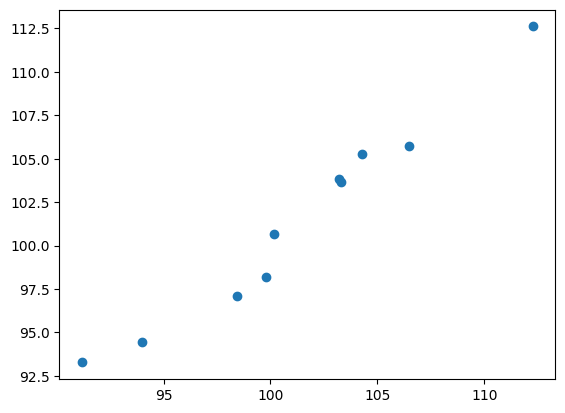

In [5]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(y, z)

# Vincent Sampling

In [6]:
# Optimal design?
Base    = Ppi(pik)              # eigenbasis
Ppi_mat = Base @ Base.T         # K = P^Pi
Dpi_inv = np.diag(1.0 / pik)
I_N     = np.eye(N)

A = (I_N - Ppi_mat) * Ppi_mat   # K ⊙ (I - K)

var_dsd_z = float(z.T @ Dpi_inv @ A @ Dpi_inv @ z)
var_dsd_y = float(y.T @ Dpi_inv @ A @ Dpi_inv @ y)

# SRS variances
var_srs_z = N**2 * (1 - n / N) * np.var(z, ddof=1) / n
var_srs_y = N**2 * (1 - n / N) * np.var(y, ddof=1) / n

eff_y_optimal = var_srs_y / var_dsd_y
eff_z_optimal = var_srs_z / var_dsd_z

In [7]:
import numpy as np
import pandas as pd

m_pi = np.array(pik, dtype=float)

# 1) sort π, y, z consistently
perm        = np.argsort(m_pi)[::-1]
m_pi_sorted = m_pi[perm]
y_sorted    = y[perm]
z_sorted    = z[perm]

N   = len(m_pi_sorted)
I_N = np.eye(N)

# 2) fixed size: M must equal n = sum(pi) (and be an integer)
n_target = m_pi_sorted.sum()
n_int    = int(round(n_target))

M = n_int

max_eff_y = 0.0
max_eff_z = 0.0
num_iter  = 10000

for it in range(num_iter):
    omega = np.random.rand(M, N)
    rho   = np.random.rand(M, N - 1)

    K = CaDsd(pi=m_pi_sorted, M=M, omega=omega, rho=rho)
    Kmat = K["K"].astype(np.complex128)
    best_K = Kmat
    # 3) enforce Hermitian
    # Kmat = 0.5 * (Kmat + Kmat.conj().T)

    # 4) check that diag(K) matches π (inclusion probs)
    diag_K = np.real(np.diag(Kmat))
    if not np.allclose(diag_K, m_pi_sorted, atol=1e-5):

        continue  # reject: π not respected

    # 5) check projection / fixed size: eigenvalues in {0,1} and sum ≈ n
    evals = np.linalg.eigvalsh(Kmat)
    
    if not (np.all(evals >= -1e-5) and np.all(evals <= 1 + 1e-5)):
    
         continue
    if not np.isclose(evals.sum(), n_int, atol=1e-5):
        continue  # reject: not trace n

    # 6) use exact π in Dπ⁻¹ (π respected "exactly")
    Dpi_inv = np.diag(1.0 / m_pi_sorted)

    # complex variance operator: A = K ⊙ (I - \bar K)
    A = Kmat * (I_N - Kmat.conj())

    var_y_rand = float(np.real(y_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ y_sorted))
    var_z_rand = float(np.real(z_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ z_sorted))

    
    eff_y_rand = var_srs_y / var_y_rand
    eff_z_rand = var_srs_z / var_z_rand

    if eff_z_rand > max_eff_z:
        max_eff_y = eff_y_rand
        max_eff_z = eff_z_rand
        best_k = Kmat

    print(
        f"iter: {it+1}/{num_iter}, "
        f"eff_z_rand: {max_eff_z:.2f}, eff_y_rand: {max_eff_y:.2f}, "
        f"eff_z_opt: {eff_z_optimal:.2f}, eff_y_opt: {eff_y_optimal:.2f}",
        end="\r",
        flush=True,
    )

print(
    f"\nFINAL -> eff_z_rand: {max_eff_z:.2f}, eff_y_rand: {max_eff_y:.2f}, "
    f"eff_z_opt: {eff_z_optimal:.2f}, eff_y_opt: {eff_y_optimal:.2f}"
)
print(pd.DataFrame({'pik': m_pi_sorted,
                    'diag': np.diag(best_K),
                    'eign': np.linalg.eigvalsh(best_K)}   ))

iter: 10000/10000, eff_z_rand: 5.72, eff_y_rand: 4.07, eff_z_opt: 3.38, eff_y_opt: 3.11
FINAL -> eff_z_rand: 5.72, eff_y_rand: 4.07, eff_z_opt: 3.38, eff_y_opt: 3.11
        pik                diag          eign
0  0.326806  0.326806+0.000000j -1.238756e-07
1  0.314167  0.314167+0.000000j -7.690216e-08
2  0.309558  0.309558+0.000000j -5.040768e-08
3  0.308485  0.308485+0.000000j  2.478326e-08
4  0.302923  0.302923+0.000000j  6.639759e-08
5  0.302441  0.302441+0.000000j  1.097825e-07
6  0.293418  0.293418+0.000000j  1.965291e-07
7  0.287878  0.287878+0.000000j  9.999991e-01
8  0.282251  0.282251+0.000000j  9.999996e-01
9  0.272071  0.272071+0.000000j  1.000000e+00


# For Searching around an efficient K

In [ ]:
base <- Reciprocal_CaDsd(K0)
omega0 <- base$omega  # M × N
rho0   <- base$rho    # M × (N-1)


eps_omega = 0.02   # step size
eps_rho   = 0.02

omega_new = omega0 + eps_omega * (2 * np.random.rand(*omega0.shape) - 1)
rho_new   = rho0   + eps_rho   * (2 * np.random.rand(*rho0.shape) - 1)

# keep them in [0,1]
omega_new = np.clip(omega_new, 0.0, 1.0)
rho_new   = np.clip(rho_new,   0.0, 1.0)


In [ ]:
K = CaDsd(pi=m_pi_sorted, M=M, omega=omega_new, rho=rho_new)
Kmat = K["K"].astype(np.complex128)
Kmat = 0.5 * (Kmat + Kmat.conj().T)             # enforce Hermitian

diag_K = np.real(np.diag(Kmat))
if not np.allclose(diag_K, m_pi_sorted, atol=1e-6):
    reject  # π not respected

evals = np.linalg.eigvalsh(Kmat)
if not (np.all(evals >= -1e-6) and np.all(evals <= 1 + 1e-6)):
    reject  # not contracting / projection-like


In [ ]:
Dpi_inv = np.diag(1.0 / m_pi_sorted)
A = Kmat * (I_N - Kmat.conj())

var_y = float(np.real(y_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ y_sorted))
var_z = float(np.real(z_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ z_sorted))
